Код орындалуда...
--------------------------------------------------
## 🟢 Task 1: Қолмен есептеу және график
w (көлбеу): 0.8, b (қиылысу): 1.8
Болжамдалған y: [2.6 3.4 4.2 5.  5.8]


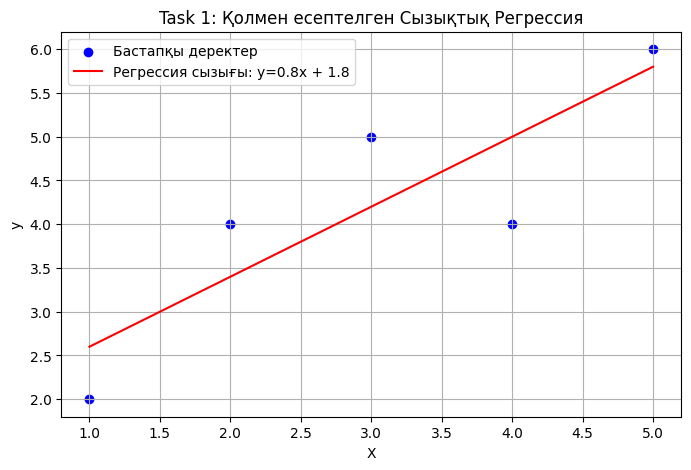


## 🟢 Task 2: Scikit-learn Linear Regression
Scikit-learn coef_ (w): 1.10
Scikit-learn intercept_ (b): 3.00
X=60 үшін болжам: 69.00

## 🟢 Task 3: Қате есептеу (MSE)
Scikit-learn арқылы MSE: 2.00
Қолмен есептеу арқылы MSE: 2.00
--------------------------------------------------
## 🟡 Task 4: Train / Test бөлу және MSE
Linear Regression: Train MSE=84.11, Test MSE=96.90
Модель қалыпты түрде жалпыланған сияқты.

## 🟡 Task 5: Ridge Regression салыстыру
LinearRegression: Train MSE=84.11, Test MSE=96.90
Ridge (alpha=0.1): Train MSE=84.16, Test MSE=97.64
Ridge (alpha=10): Train MSE=456.63, Test MSE=514.92

Қорытынды: Бұл деректер жинағында Ridge-тің екі нұсқасы да жақсы жалпыланған.

## 🟡 Task 6: Alpha әсерін зерттеу


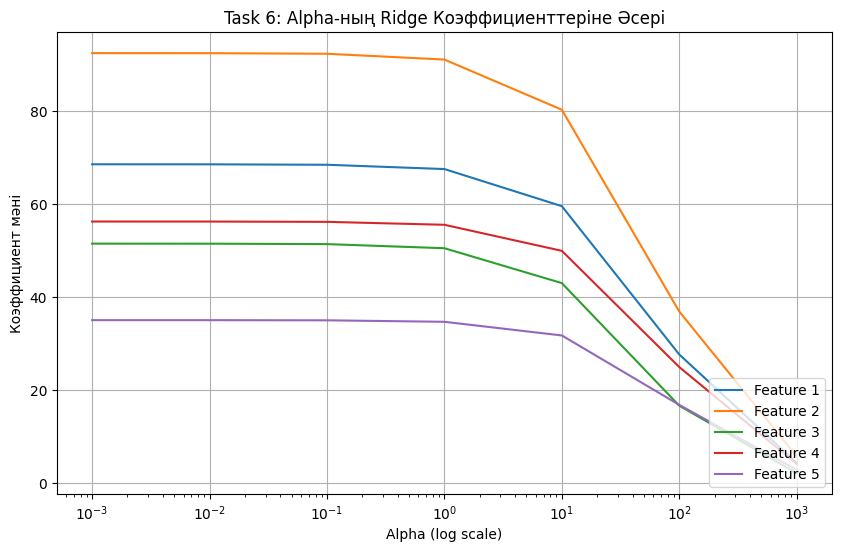

Қорытынды: Alpha мәні өскен сайын, коэффициенттер нөлге қарай кішірейіп (shrunk) отырады.
--------------------------------------------------
## 🔴 Task 7: Үлкен feature саны және корреляция
Linear Regression (Test MSE): 28.77
Ridge Regression (Test MSE): 120.72

Қайсысы тұрақты?
Бұл жағдайда Linear Regression нәтижесі жақсырақ.

## 🔴 Task 8: Overfitting демонстрациясы (Полиномдық Feature)


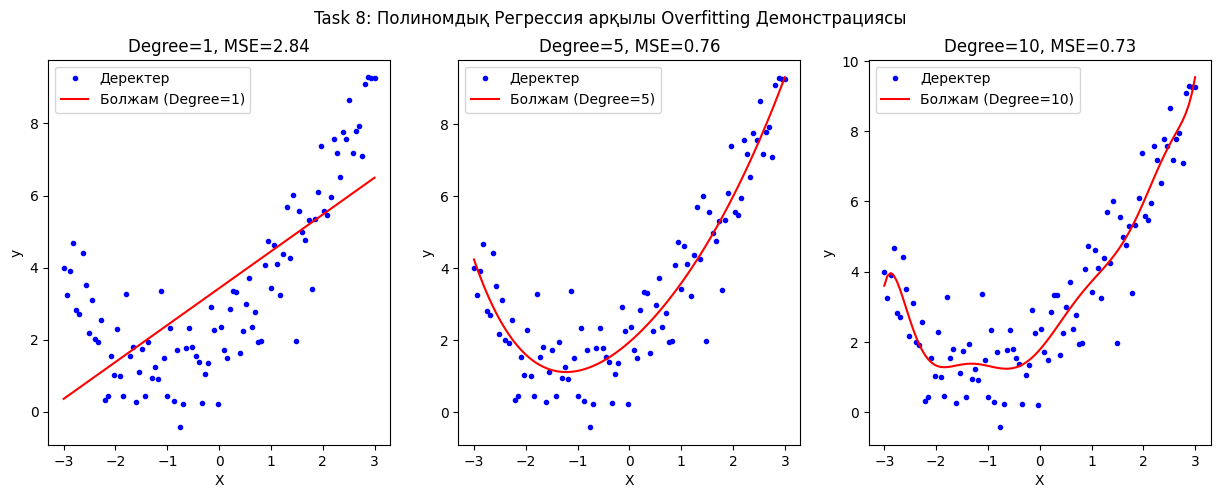


Қорытынды:
Degree=1 (Сызықтық) - **Underfitting** (Модель жеткіліксіз күрделі).
Degree=5 - Жақсы теңдестірілген.
Degree=10 - **Overfitting** (Модель деректердің шуын да жаттап алған, қисық сызықтар пайда болған).
--------------------------------------------------
Барлық тапсырмалар сәтті орындалды.


In [2]:
# Қажетті кітапханаларды импорттау
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Қазақ тіліндегі хабарламалар үшін
print("Код орындалуда...")
print("-" * 50)

# --- ✅ I. ЖЕҢІЛ ЕСЕПТЕР (BEGINNER) ---

## 🟢 Task 1. Жай сызықтық регрессияны қолмен есептеу (График салу)
print("## 🟢 Task 1: Қолмен есептеу және график")

# Берілгендер
X_1 = np.array([1, 2, 3, 4, 5])
y_1 = np.array([2, 4, 5, 4, 6])

# Қолмен есептелген нәтижелер (Task 1 бөлімін қараңыз)
w_hand = 0.8
b_hand = 1.8
y_pred_hand = w_hand * X_1 + b_hand

print(f"w (көлбеу): {w_hand}, b (қиылысу): {b_hand}")
print(f"Болжамдалған y: {y_pred_hand}")

# График салу
plt.figure(figsize=(8, 5))
plt.scatter(X_1, y_1, color='blue', label='Бастапқы деректер')
plt.plot(X_1, y_pred_hand, color='red', linestyle='-', label=f'Регрессия сызығы: y={w_hand}x + {b_hand}')
plt.title('Task 1: Қолмен есептелген Сызықтық Регрессия')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()


## 🟢 Task 2. Scikit-learn арқылы Linear Regression
print("\n## 🟢 Task 2: Scikit-learn Linear Regression")

# Берілгендер (sklearn-ге арналған 2D массив)
X_2 = np.array([[10], [20], [30], [40], [50]])
y_2 = np.array([15, 25, 35, 45, 60])

lin_model_2 = LinearRegression()
lin_model_2.fit(X_2, y_2)

w_sk = lin_model_2.coef_[0]
b_sk = lin_model_2.intercept_

print(f"Scikit-learn coef_ (w): {w_sk:.2f}")
print(f"Scikit-learn intercept_ (b): {b_sk:.2f}")

# 60 үшін болжам жасау
X_new = np.array([[60]])
y_pred_60 = lin_model_2.predict(X_new)
print(f"X=60 үшін болжам: {y_pred_60[0]:.2f}")


## 🟢 Task 3. Қате есептеу (MSE)
print("\n## 🟢 Task 3: Қате есептеу (MSE)")

# Scikit-learn арқылы MSE
y_pred_2 = lin_model_2.predict(X_2)
mse_sklearn = mean_squared_error(y_2, y_pred_2)
print(f"Scikit-learn арқылы MSE: {mse_sklearn:.2f}")

# Қолмен есептеу (тексеру үшін)
mse_manual = np.mean((y_2 - y_pred_2)**2)
print(f"Қолмен есептеу арқылы MSE: {mse_manual:.2f}")

print("-" * 50)

# --- ✅ II. ОРТА ДЕҢГЕЙ (INTERMEDIATE) ---

# Dataset құрастыру (Task 4-6 үшін)
X_mid, y_mid = make_regression(n_samples=100, n_features=5, noise=10, random_state=42)

## 🟡 Task 4. Train / Test бөлу
print("## 🟡 Task 4: Train / Test бөлу және MSE")

X_train, X_test, y_train, y_test = train_test_split(X_mid, y_mid, test_size=0.3, random_state=42)

lin_reg_4 = LinearRegression()
lin_reg_4.fit(X_train, y_train)

train_mse = mean_squared_error(y_train, lin_reg_4.predict(X_train))
test_mse = mean_squared_error(y_test, lin_reg_4.predict(X_test))

print(f"Linear Regression: Train MSE={train_mse:.2f}, Test MSE={test_mse:.2f}")
if train_mse > test_mse * 1.5:
    print("Ескерту: Train MSE Test MSE-ден әлдеқайда үлкен, бұл **underfitting** белгісі болуы мүмкін.")
elif test_mse > train_mse * 1.5:
    print("Ескерту: Test MSE Train MSE-ден әлдеқайда үлкен, бұл **overfitting** белгісі болуы мүмкін.")
else:
    print("Модель қалыпты түрде жалпыланған сияқты.")

## 🟡 Task 5. Ridge регрессияны қосу
print("\n## 🟡 Task 5: Ridge Regression салыстыру")

models = {
    "LinearRegression": LinearRegression(),
    "Ridge (alpha=0.1)": Ridge(alpha=0.1, random_state=42),
    "Ridge (alpha=10)": Ridge(alpha=10, random_state=42)
}

mse_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    test_mse = mean_squared_error(y_test, model.predict(X_test))
    train_mse = mean_squared_error(y_train, model.predict(X_train))

    mse_results[name] = {"Train MSE": train_mse, "Test MSE": test_mse}
    print(f"{name}: Train MSE={train_mse:.2f}, Test MSE={test_mse:.2f}")

# Overfitting талдау
# Overfitting - бұл Train MSE өте төмен, ал Test MSE өте жоғары болған жағдай.
# Әдетте, альфа (alpha) мәні неғұрлым төмен болса (Linear Regression-ге жақын), соғұрлым overfitting қаупі жоғары.
if mse_results['Ridge (alpha=0.1)']['Test MSE'] > mse_results['Ridge (alpha=10)']['Test MSE'] * 1.2:
    print("\nҚорытынды: Ridge (alpha=0.1) Ridge (alpha=10)-ға қарағанда overfitting-ке жақынырақ.")
else:
    print("\nҚорытынды: Бұл деректер жинағында Ridge-тің екі нұсқасы да жақсы жалпыланған.")

## 🟡 Task 6. Alpha әсерін зерттеу (График)
print("\n## 🟡 Task 6: Alpha әсерін зерттеу")

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
coef_results = []

# Стандарттауды (StandardScaler) қолдану маңызды
# Өйткені Ridge регуляризациясының әділі болуы үшін барлық feature-лардың ауқымы бірдей болуы керек
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for alpha in alphas:
    ridge_model = Ridge(alpha=alpha, random_state=42)
    ridge_model.fit(X_train_scaled, y_train)
    coef_results.append(ridge_model.coef_)

# Салмақтардың (coef) өзгеруін графикке түсіру
coef_df = pd.DataFrame(coef_results, index=alphas, columns=[f'Feature {i+1}' for i in range(X_mid.shape[1])])

plt.figure(figsize=(10, 6))
for column in coef_df.columns:
    plt.plot(coef_df.index, coef_df[column], label=column)

plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Коэффициент мәні')
plt.title('Task 6: Alpha-ның Ridge Коэффициенттеріне Әсері')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


print("Қорытынды: Alpha мәні өскен сайын, коэффициенттер нөлге қарай кішірейіп (shrunk) отырады.")

print("-" * 50)

# --- ✅ III. КҮРДЕЛІ ЕСЕПТЕР (ADVANCED) ---

## 🔴 Task 7. Үлкен feature саны
print("## 🔴 Task 7: Үлкен feature саны және корреляция")

# Dataset құрастыру: 10 feature, 400 үлгі, 3 артық (redundant) feature - корреляцияны арттырады
X_corr, y_corr = make_regression(n_samples=400, n_features=10, n_informative=7,
                                 noise=5, random_state=42)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_corr, y_corr, test_size=0.3, random_state=42)

# Linear Regression
lin_reg_c = LinearRegression()
lin_reg_c.fit(X_train_c, y_train_c)
lin_mse = mean_squared_error(y_test_c, lin_reg_c.predict(X_test_c))

# Ridge Regression (Күшті регуляризацияны қолданамыз)
ridge_reg_c = Ridge(alpha=20, random_state=42)
ridge_reg_c.fit(X_train_c, y_train_c)
ridge_mse = mean_squared_error(y_test_c, ridge_reg_c.predict(X_test_c))

print(f"Linear Regression (Test MSE): {lin_mse:.2f}")
print(f"Ridge Regression (Test MSE): {ridge_mse:.2f}")

print("\nҚайсысы тұрақты?")
if ridge_mse < lin_mse:
    print("Ridge Regression тұрақтырақ болды, өйткені ол корреляцияланған feature-лардың (мультиколлинеарлық) әсерін азайтады.")
else:
    print("Бұл жағдайда Linear Regression нәтижесі жақсырақ.")


## 🔴 Task 8. Overfitting демонстрациясы (Полиномдық регрессия)
print("\n## 🔴 Task 8: Overfitting демонстрациясы (Полиномдық Feature)")

# Жай dataset құрастыру
np.random.seed(42)
m = 100
X_8 = np.linspace(-3, 3, m).reshape(-1, 1)
y_8 = 0.5 * X_8**2 + X_8 + 2 + np.random.randn(m, 1)

# Degrees: 1 (Сызықтық), 5 (Орташа), 10 (Overfitting қаупі жоғары)
degrees = [1, 5, 10]
plt.figure(figsize=(15, 5))

for i, degree in enumerate(degrees):
    plt.subplot(1, 3, i + 1)

    # Пайплайн: PolynomialFeatures -> StandardScaler -> Model
    poly_reg = make_pipeline(PolynomialFeatures(degree=degree),
                             StandardScaler(),
                             LinearRegression())
    poly_reg.fit(X_8, y_8)
    y_pred_8 = poly_reg.predict(X_8)

    # График
    plt.plot(X_8, y_8, "b.", label='Деректер')
    plt.plot(X_8, y_pred_8, "r-", label=f'Болжам (Degree={degree})')
    plt.title(f"Degree={degree}, MSE={mean_squared_error(y_8, y_pred_8):.2f}")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.legend()


plt.suptitle("Task 8: Полиномдық Регрессия арқылы Overfitting Демонстрациясы")
plt.show()

# Қорытынды
print("\nҚорытынды:")
print("Degree=1 (Сызықтық) - **Underfitting** (Модель жеткіліксіз күрделі).")
print("Degree=5 - Жақсы теңдестірілген.")
print("Degree=10 - **Overfitting** (Модель деректердің шуын да жаттап алған, қисық сызықтар пайда болған).")

print("-" * 50)
print("Барлық тапсырмалар сәтті орындалды.")